In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Implement the Softmax Function

In [ ]:
import numpy as np

def softmax(z):

    # Numerical stability
    z = z - np.max(z, axis=1, keepdims=True)

    exp_z = np.exp(z)

    softmax_probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return softmax_probs

In [ ]:
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])

softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)

assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax function passed the test case!")

Softmax function passed the test case!


**Implement Prediction Function**

In [ ]:
def predict_softmax(X, W, b):

    z = np.dot(X, W) + b

    probs = softmax(z)

    predicted_classes = np.argmax(probs, axis=1)

    return predicted_classes

In [ ]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])

W_test = np.array([[0.4, 0.2, 0.1],
                   [0.3, 0.7, 0.5]])

b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)

assert y_pred_test.shape == (3,), f"Test failed"

print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


**Implement Cross Entropy Loss**

In [ ]:
def loss_softmax(y_pred, y):

    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.sum(y * np.log(y_pred)) / y.shape[0]

    return loss

In [ ]:
# This test case compares loss for correct vs incorrect predictions

# Correct predictions (should produce LOW loss)
y_true_correct = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

y_pred_correct = np.array([
    [0.9,0.05,0.05],
    [0.1,0.85,0.05],
    [0.05,0.1,0.85]
])

# Incorrect predictions (should produce HIGH loss)
y_pred_incorrect = np.array([
    [0.05,0.05,0.9],
    [0.1,0.05,0.85],
    [0.85,0.1,0.05]
])

# Calculate loss
loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

# Check if correct predictions have lower loss
assert loss_correct < loss_incorrect, f"Test failed: Expected loss_correct < loss_incorrect, but got {loss_correct:.4f} >= {loss_incorrect:.4f}"

# Print results
print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


**Implement Cost Function**

In [ ]:
def softmax(z):

    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))

    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
def cost_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b

    y_pred = softmax(z)

    total_loss = -np.sum(y * np.log(y_pred))

    return total_loss / n

In [ ]:
# The test case assures that incorrect predictions should have higher cost

# Example 1: Correct Prediction
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

# Example 2: Incorrect Prediction
X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

# Compute cost
cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

# Test condition
assert cost_incorrect > cost_correct, f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"

print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


**Compute Gradients**

In [ ]:
def compute_gradient_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b

    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n

    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

In [ ]:
import numpy as np
# Define a simple feature matrix and true labels
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]]) # Feature matrix (3 samples, 2 features)
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]) # True labels (one-hot encoded, 3 classes)
# Define weight matrix and bias vector
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]]) # Weights (2 features, 3 classes)
b_test = np.array([0.1, 0.2, 0.3]) # Bias (3 classes)
# Compute the gradients using the function
grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)
# Manually compute the predicted probabilities (using softmax function)
z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)
# Compute the manually computed gradients
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]
# Assert that the gradients computed by the function match the manually computed gradients
assert np.allclose(grad_W, grad_W_manual), f"Test failed: Gradients w.r.t. W are not equal.\
nExpected: {grad_W_manual}\nGot: {grad_W}"
assert np.allclose(grad_b, grad_b_manual), f"Test failed: Gradients w.r.t. b are not equal.\
nExpected: {grad_b_manual}\nGot: {grad_b}"
# Print the gradients for verification
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


**Implement Gradient Descent**

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):

    cost_history = []

    for i in range(n_iter):

        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)

        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return W, b, cost_history

**Load and Prepare MNIST Dataset**

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

def load_and_prepare_mnist(file_path, test_size=0.2, random_state=42):

    df = pd.read_csv(file_path)

    y = df.iloc[:,0].values
    X = df.iloc[:,1:].values

    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

In [20]:
import matplotlib.pyplot as plt

def plot_sample_images(X, y, num_images=5):
    """
    Plots first few sample images from the dataset.
    X : np.array of shape (num_samples, 784)
    y : labels
    num_images : how many images to show
    """
    plt.figure(figsize=(10, 2))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(X[i].reshape(28,28), cmap='gray')
        plt.title(f"Label: {y[i]}")
        plt.axis('off')
    plt.show()

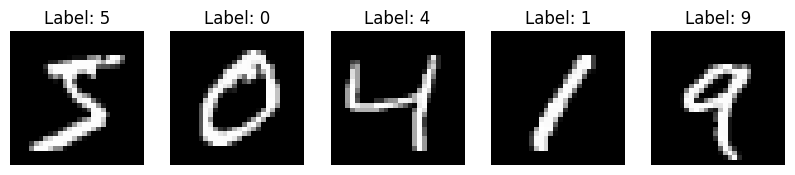

In [21]:
X_train, X_test, y_train, y_test = load_and_prepare_mnist(
    "/content/drive/MyDrive/AI/Data/mnist_dataset.csv"
)

In [22]:
assert len(X_train) == len(y_train), f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
print("Move forward: Dimension of feature matrix X and label vector y matched.")

Move forward: Dimension of feature matrix X and label vector y matched.


In [23]:
from sklearn.preprocessing import OneHotEncoder

# Check if y_train is 1D, then one-hot encode
if len(y_train.shape) == 1 or y_train.shape[1] == 1:
    encoder = OneHotEncoder(sparse_output=False)  # sparse_output=False for newer sklearn
    y_train = encoder.fit_transform(y_train.reshape(-1,1))
    y_test = encoder.transform(y_test.reshape(-1,1))

print(f"y_train shape after one-hot: {y_train.shape}")
print(f"y_test shape after one-hot: {y_test.shape}")

y_train shape after one-hot: (48000, 10)
y_test shape after one-hot: (12000, 10)


In [24]:
d = X_train.shape[1]  # Number of features
c = y_train.shape[1]  # Number of classes

W = np.random.randn(d, c) * 0.01  # Small random weights
b = np.zeros(c)                   # Bias initialized to 0

In [35]:
alpha = 0.1     # Learning rate
n_iter = 100   # Number of iterations

In [36]:
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)

Iteration 0, Cost: 2.2008184222875617


In [37]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []
    n = X.shape[0]

    for i in range(n_iter):
        # Forward pass
        z = np.dot(X, W) + b
        y_pred = softmax(z)

        # Compute cost
        cost = -np.sum(y * np.log(y_pred)) / n
        cost_history.append(cost)

        # Gradients
        dW = np.dot(X.T, (y_pred - y)) / n
        db = np.sum(y_pred - y, axis=0) / n

        # Update weights
        W -= alpha * dW
        b -= alpha * db

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")

    return W, b, cost_history

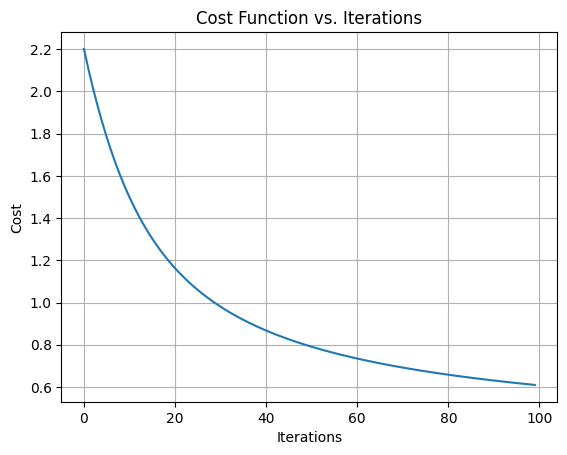

In [38]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [39]:
print("Shape of W_opt:", W_opt.shape)
print("Shape of b_opt:", b_opt.shape)

# View first 5 weights for the first class
print("First 5 weights for class 0:", W_opt[:5,0])

# View trained biases
print("Trained biases:", b_opt)

Shape of W_opt: (784, 10)
Shape of b_opt: (10,)
First 5 weights for class 0: [-0.02086967 -0.00776558  0.00829247 -0.00203512  0.00095133]
Trained biases: [-0.04677834  0.10695112 -0.02545742 -0.03257863  0.02970114  0.05943784
 -0.01233268  0.04781095 -0.11209699 -0.014657  ]


**Evaluating the Model**

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Evaluation Function
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.

    Parameters:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted labels

    Returns:
    tuple: Confusion matrix, precision, recall, F1 score
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1


Confusion Matrix:
[[1104    0    7    2    5   11   25    3   14    4]
 [   0 1248   10   12    1    7    2    2   39    1]
 [   9   30  965   13   25    1   47   32   41   11]
 [  17   11   39 1024    2   38   13   12   39   24]
 [   1   11    7    0 1029    2   16    6    9   95]
 [  31   38   11   96   25  786   24   10   55   28]
 [  12   13   31    1   11   19 1080    2    8    0]
 [  12   49   23    2   21    2    0 1134   14   42]
 [   9   45   15   65   13   32   11    8  938   24]
 [  16   20   12   17   60    9    2   53   12  993]]
Precision: 0.86
Recall: 0.86
F1-Score: 0.86


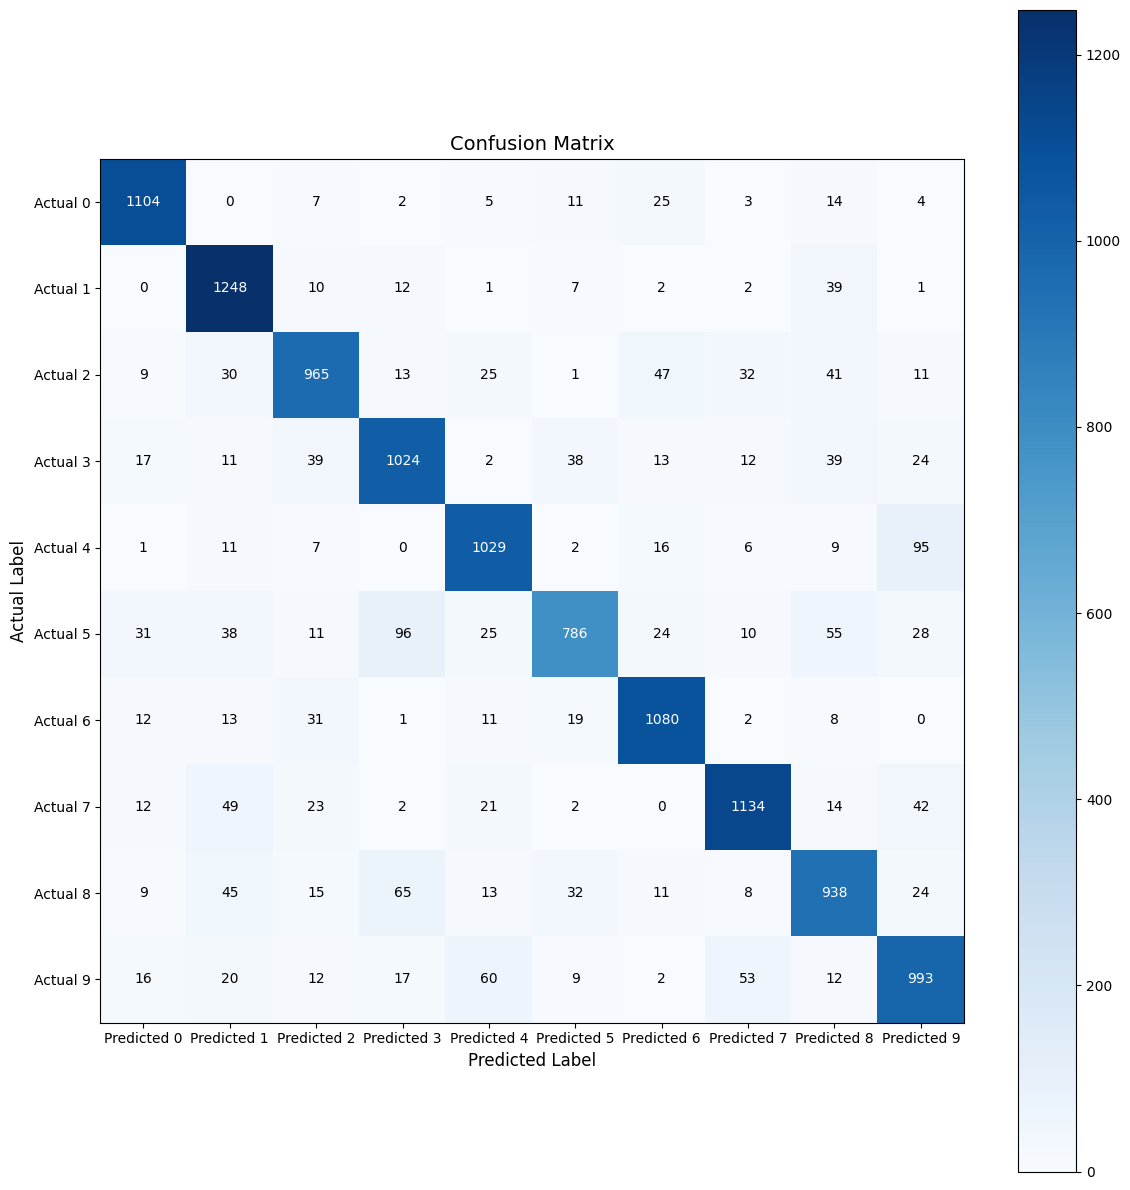

In [43]:
# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)  # True labels in numeric form

# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Visualizing the Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')  # Use a color map for better visualization

# Dynamic number of classes
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

# Add labels to each cell in the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center', va='center',
            color='white' if cm[i, j] > np.max(cm) / 2 else 'black'
        )

# Add title and axis labels
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

# Add colorbar
plt.colorbar(cax)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

**Linear Separability and Logistic Regression.**

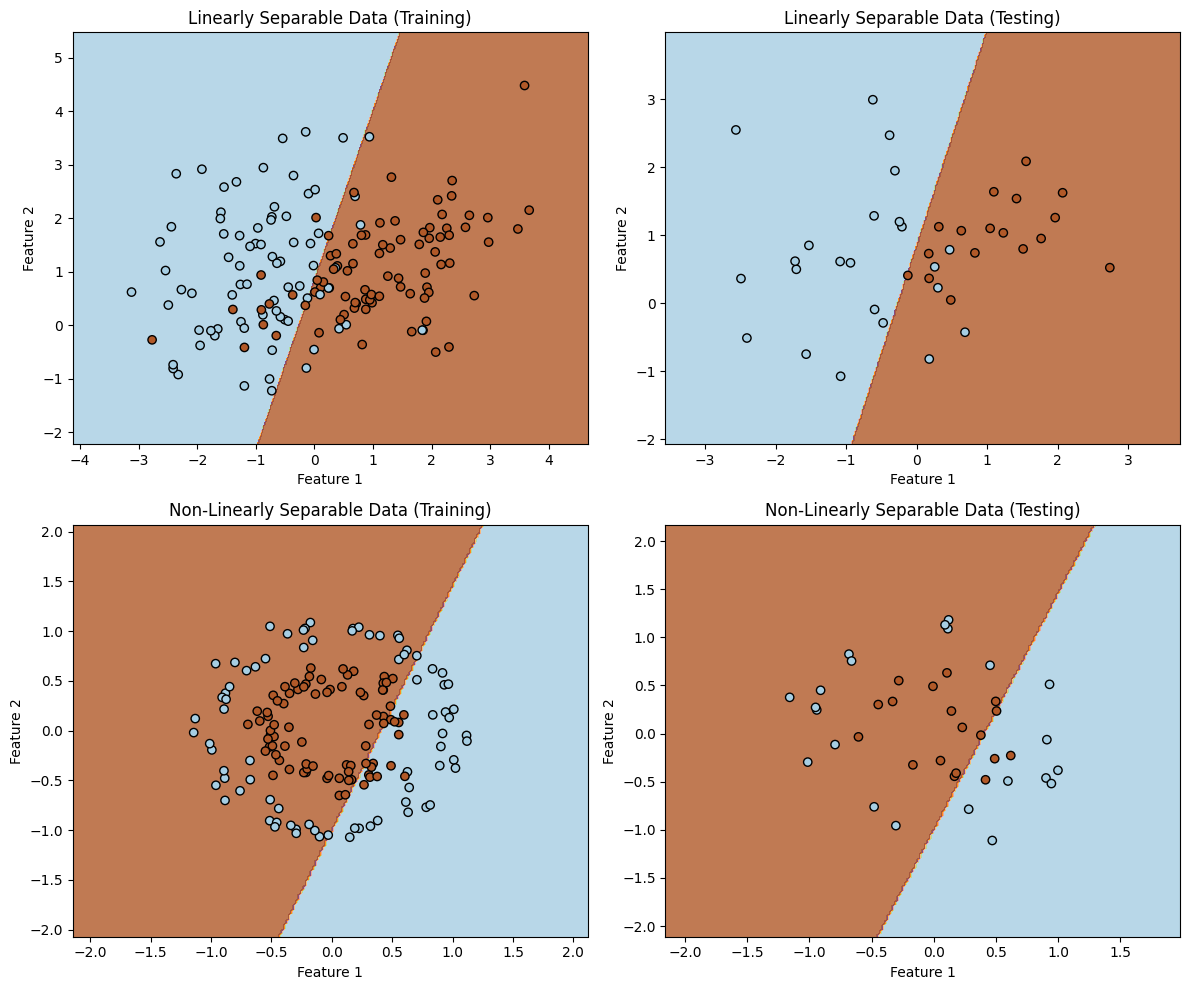

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Set random seed for reproducibility
np.random.seed(42)

# ---------------------------
# Generate linearly separable dataset
# ---------------------------
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2,
    n_informative=2, n_redundant=0, n_clusters_per_class=1,
    random_state=42
)

# Split into training and testing
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# ---------------------------
# Generate non-linearly separable dataset (circles)
# ---------------------------
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

# Split into training and testing
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# ---------------------------
# Function to plot decision boundaries
# ---------------------------
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# ---------------------------
# Plot decision boundaries
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Linearly separable data (training)
plot_decision_boundary(axes[0, 0], logistic_model_linear_separable, X_train_linear, y_train_linear,
                       'Linearly Separable Data (Training)')

# Linearly separable data (testing)
plot_decision_boundary(axes[0, 1], logistic_model_linear_separable, X_test_linear, y_test_linear,
                       'Linearly Separable Data (Testing)')

# Non-linearly separable data (training)
plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable, X_train_non_linear,
                       y_train_non_linear, 'Non-Linearly Separable Data (Training)')

# Non-linearly separable data (testing)
plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable, X_test_non_linear,
                       y_test_non_linear, 'Non-Linearly Separable Data (Testing)')

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

Question 1

Is extracting pixel values sufficient for effective feature extraction? Why or why not?

Answer:

Extracting pixel values alone is not always sufficient for effective feature extraction because raw pixels only represent intensity values and do not capture higher-level patterns such as edges, shapes, or textures. However, for datasets like MNIST where images are simple and centered, raw pixel values can still work reasonably well for classification. In more complex datasets, advanced feature extraction techniques such as convolutional neural networks (CNNs) or feature engineering are required.

Question 2

Interpret the output of the plots

Answer:

For the linearly separable dataset, logistic regression successfully learns a linear decision boundary that separates the two classes clearly, resulting in good classification performance. However, for the non-linearly separable dataset (circles), logistic regression struggles because it can only create linear decision boundaries. As a result, the model cannot properly separate the circular classes, leading to misclassification.

Question 3

Challenges faced

Answer:

Some challenges during implementation include handling matrix dimensions correctly, implementing the softmax function with numerical stability, and computing gradients accurately for gradient descent. Another challenge was ensuring that labels were properly one-hot encoded and that the training process converged by selecting appropriate learning rate and number of iterations.